In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial_one_10tasks_10eps_modelonly/metrics/episodes_metrics.csv')
df.head()

,total_episode_idx,task_id,episode_idx,task_description,success,termination_reason,exception,step_count,num_policy_queries,action_chunk_smoothness,...,video_latent_cosine_initial_final,video_latent_cosine_t_t1_mean,video_latent_delta_l2_mean,video_latent_delta_l2_std,video_latent_entropy,video_latent_norm_mean,video_latent_norm_std,video_latent_temporal_consistency,video_latent_temporal_smoothness,video_latent_variance_mean
0,3,0,2,pick up the bowl between the plate and the ram...,False,timeout,NaN,220,44,0.762893,...,0.456202,0.508309,137.522265,29.345477,0.990910,140.288584,26.762361,0.508309,0.032956,6.347553
1,4,0,3,pick up the bowl between the plate and the ram...,False,timeout,NaN,220,44,0.806959,...,0.462167,0.511669,137.433208,29.238686,0.990960,140.605526,26.761757,0.511669,0.033074,6.303105
2,5,0,4,pick up the bowl between the plate and the ram...,False,timeout,NaN,220,44,0.797586,...,0.458932,0.510821,137.411207,29.227558,0.990939,140.492139,26.773728,0.510821,0.033085,6.303242
3,6,0,5,pick up the bowl between the plate and the ram...,False,timeout,NaN,220,44,0.755040,...,0.458895,0.506124,137.668923,29.435383,0.990852,140.149494,26.813605,0.506124,0.032858,6.370564
4,7,0,6,pick up the bowl between the plate and the ram...,False,timeout,NaN,220,44,0.765557,...,0.463381,0.509473,137.453177,29.180943,0.990968,140.371650,26.695987,0.509473,0.033137,6.324376


In [5]:
not_metric_features = ['task_id', 'episode_idx', 'total_episode_idx', 'task_description', 'success', 'termination_reason', 'exception', 'step_count', 'num_policy_queries']
df_success = df[df.success == True]
df_failure = df[df.success == False]
len(df_success) , len(df_failure)

(72, 26)

In [6]:
metrices_success = df_success.drop(not_metric_features, axis=1)
metrices_failure = df_failure.drop(not_metric_features, axis=1)

In [7]:
mean_success = metrices_success.mean(axis=0)
mean_failure = metrices_failure.mean(axis=0)
sub_means = np.array(mean_success - mean_failure)

In [ ]:
delete_features = ['tri_modal_alignment_score', 'cross_attention_max_weight', 'attention_collapse_score', 'attention_peakiness', 'remaining_noise_norm', 'cross_attention_entropy', 'latent_freeze_fraction', 'activation_explosion_score', 'temporal_attention_stability', 'latent_update_norm', 'future_latent_prediction_error', 'partial_denoise_distance', 'video_latent_delta_l2_mean', 'latent_residual_energy', 'latent_path_length', 'future_visual_consistency', 'video_latent_temporal_consistency', 'goal_progress_velocity', 'flow_vector_norm', 'inverse_dynamics_reconstruction_error', 'plan_consistency', 'latent_motion_coherence', 'language_action_alignment', 'solver_step_error', 'latent_snr', 'causal_transition_confidence', 'video_latent_temporal_smoothness', 'video_latent_cosine_t_t1_mean', 'representation_entropy', 'latent_information_density']
# df_success[delete_features]
# 

In [50]:
features_metrices = list(set(df_success.columns) - set(not_metric_features) - set(delete_features))

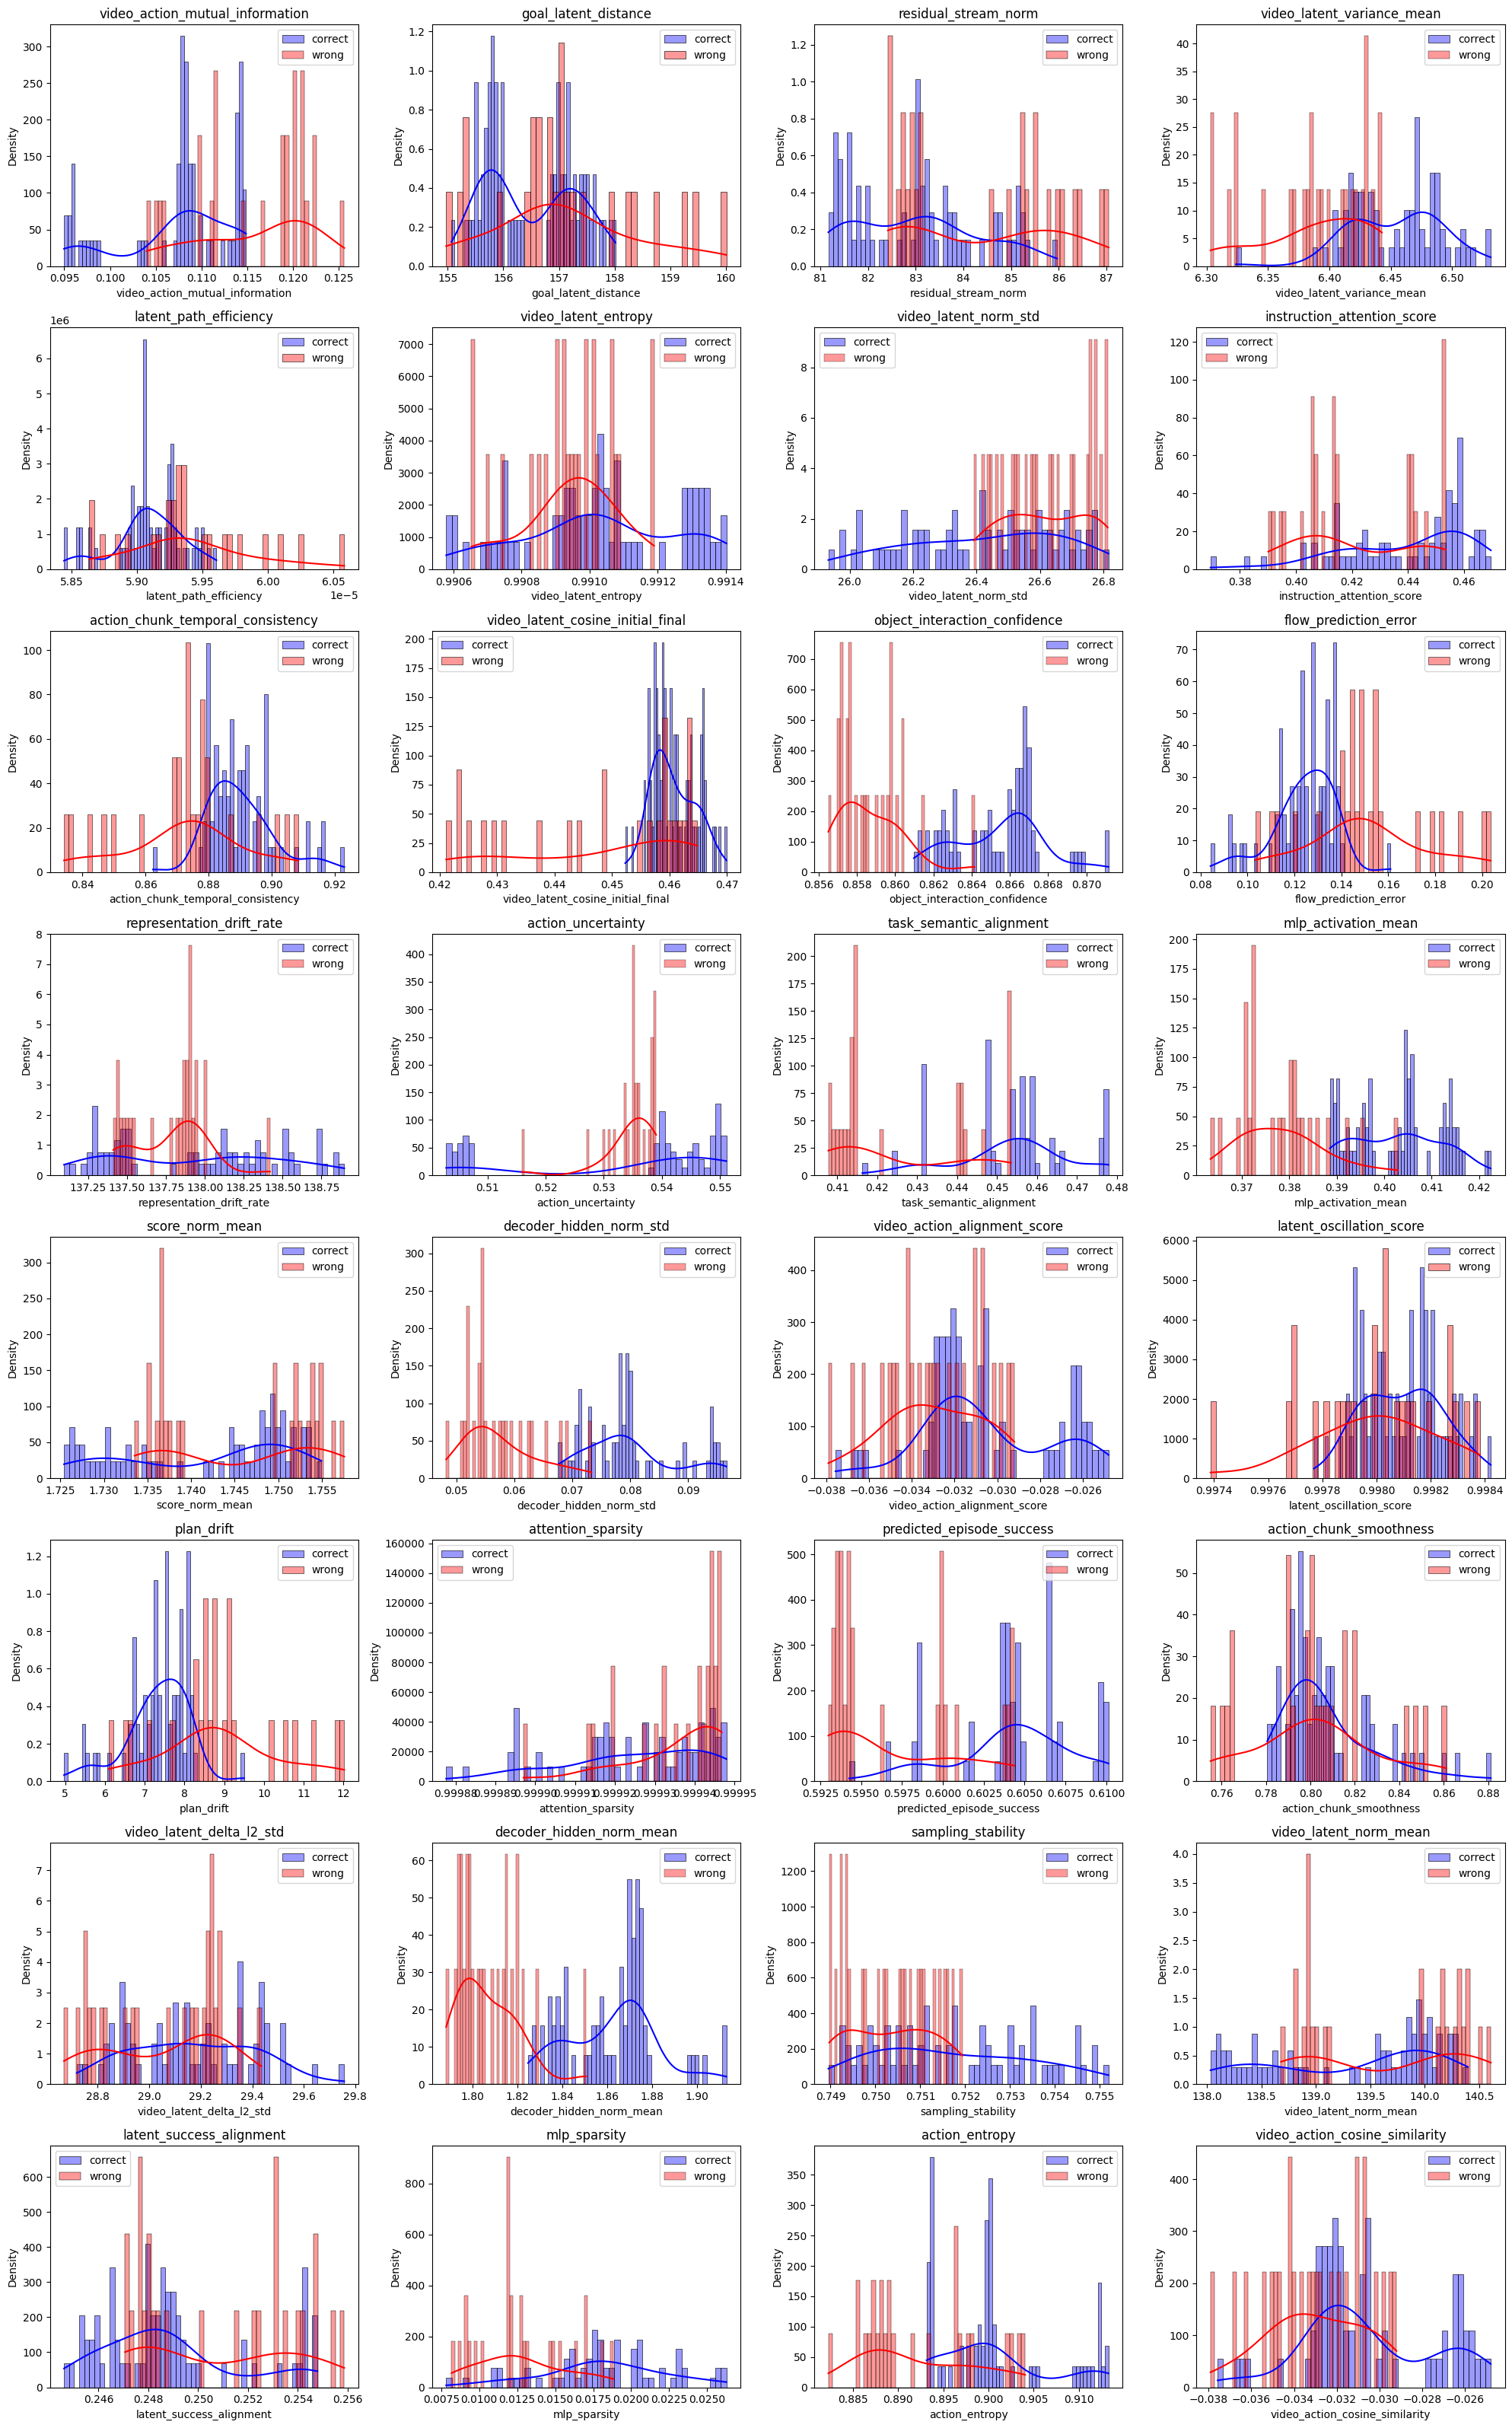

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Проверим что признаки совпадают
# assert list(df_success.columns) == list(df_wrong.columns)

features = features_metrices

# Размер сетки графиков
n_features = len(features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 4))

for i, feature in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    # распределение correct
    sns.histplot(
        df_success[feature],
        color='blue',
        label='correct',
        stat='density',
        bins=50,
        kde=True,
        alpha=0.4
    )

    # распределение wrong
    sns.histplot(
        df_failure[feature],
        color='red',
        label='wrong',
        stat='density',
        bins=50,
        kde=True,
        alpha=0.4
    )

    plt.title(feature)
    plt.legend()

plt.tight_layout()
plt.show()


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()
df_new = df.copy()
df_new[features_metrices] = scaler.fit_transform(df_new[features_metrices])

In [66]:
# best_features = ['decoder_hidden_norm_std', 'object_interaction_confidence']
df_train, df_val = train_test_split(df_new, test_size=0.2, stratify=df_new['success'])
X_train = df_train.drop(not_metric_features,axis=1)
y_train = df_train['success']
X_val = df_val.drop(not_metric_features,axis=1)
y_val = df_val['success']
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Chunk-level importance:


,feature,importance
0,task_semantic_alignment,28.317627
1,representation_drift_rate,7.737548
2,goal_latent_distance,4.759120
3,chunk_action_delta_norm_max,4.659418
4,plan_drift,3.605765
5,video_latent_entropy,3.330696
6,query_latency_sec,3.304332
7,chunk_action_delta_norm_mean,2.906916
8,video_latent_delta_l2_std,2.858762
9,latent_success_alignment,2.777593


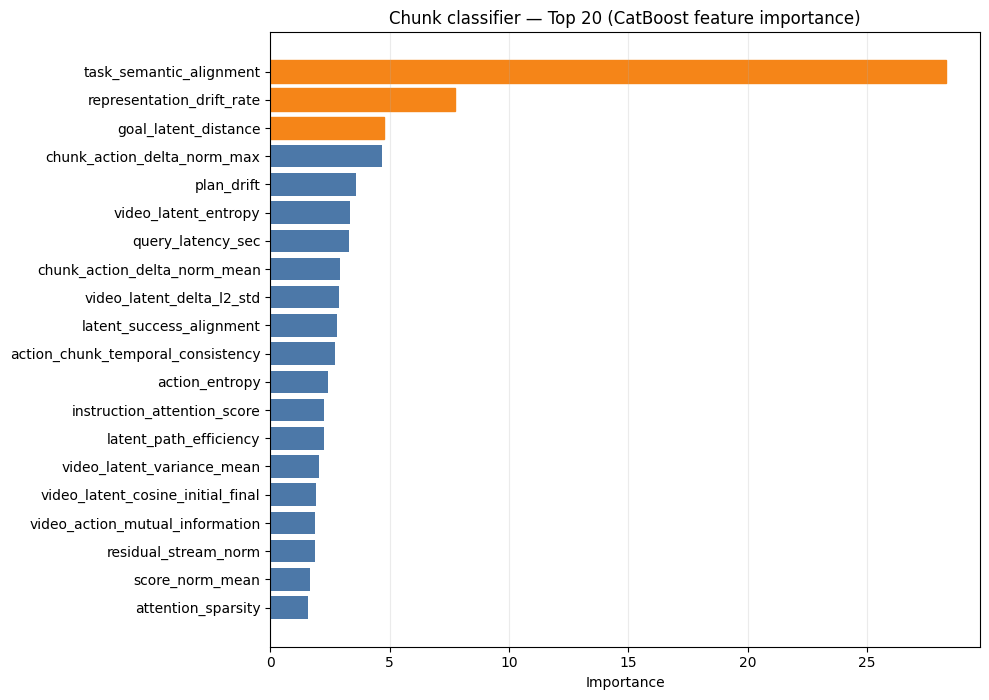

Action-level importance:


,feature,importance
0,model_gripper_command,46.253420
1,model_rotation6d_norm,15.797378
2,model_action_delta_norm,11.834688
3,model_translation_norm,11.070828
4,model_action_norm,7.482546
5,model_gripper_sign,4.719312
6,action_offset_in_chunk,2.841827


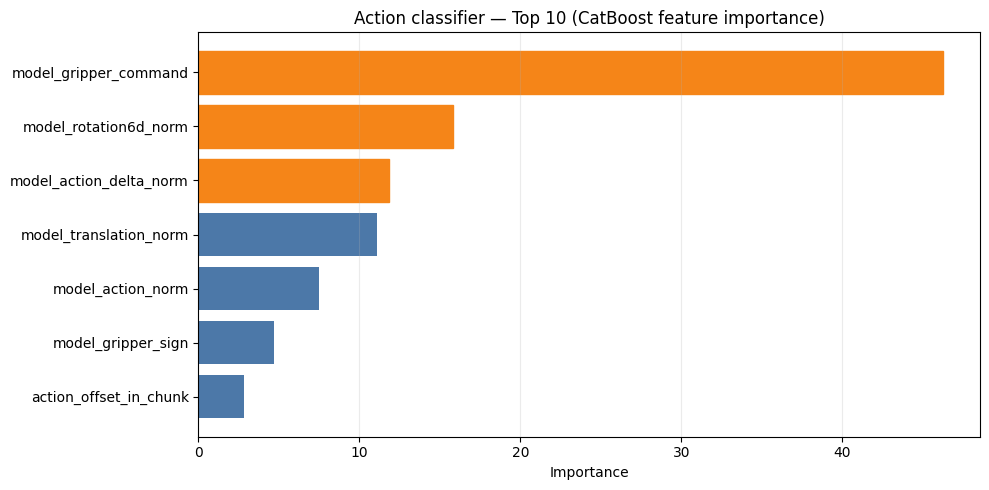

In [3]:

REPO_ROOT = Path("/home/motovilovil/Robotics/robotics_project/mimic-video")
BASE_METRICS = REPO_ROOT / "eval_outputs/libero_spatial/baseline/trace_100ep/metrics"

CHUNK_IMP = BASE_METRICS / "chunk_regeneration_classifiers_v2_70_30" / "catboost_feature_importance.csv"
ACTION_IMP = BASE_METRICS / "action_regeneration_classifiers_v2_70_30" / "catboost_action_feature_importance.csv"


def show_feature_importance(path: Path, title: str, top_n: int = 20) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Normalize column names if needed
    if "importance" not in df.columns:
        for c in df.columns:
            if c.lower() != "feature" and "import" in c.lower():
                df = df.rename(columns={c: "importance"})
                break

    df = df[["feature", "importance"]].copy()
    df["importance"] = pd.to_numeric(df["importance"], errors="coerce").fillna(0.0)
    df = df.sort_values("importance", ascending=False)

    display(df.head(top_n))

    top = df.head(top_n).iloc[::-1]
    fig_h = max(5, 0.28 * len(top) + 1.5)
    plt.figure(figsize=(10, fig_h))
    bars = plt.barh(top["feature"], top["importance"], color="#4C78A8")

    # Highlight top-3
    for i, b in enumerate(bars):
        if i >= len(bars) - 3:
            b.set_color("#F58518")

    plt.title(f"{title} — Top {top_n} (CatBoost feature importance)")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return df


print("Chunk-level importance:")
chunk_imp = show_feature_importance(CHUNK_IMP, "Chunk classifier", top_n=20)

print("Action-level importance:")
action_imp = show_feature_importance(ACTION_IMP, "Action classifier", top_n=10)


In [68]:
y_pred = model.predict(X_train)
accuracy_score(y_train, y_pred)

1.0

In [5]:
df = pd.read_csv('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial_one_10tasks_10eps_device3_trace_modelonly/metrics/chunk_jsd_analysis/chunk_metric_jsd_top10_per_chunk.csv')
df.head()

,metric,chunk_id,jsd,js_distance,n_success,n_failure,success_mean,failure_mean,success_median,failure_median,mean_diff_failure_minus_success,histogram_bins,rank_within_chunk,rank_global
0,chunk_action_delta_norm_mean,0,0.601896,0.775819,69,31,0.088054,0.106239,0.082914,0.107324,0.018185,20,1,39
1,chunk_action_variance,0,0.540429,0.735139,69,31,0.234418,0.239948,0.232697,0.242320,0.005530,20,2,60
2,video_action_alignment_score,0,0.488102,0.698643,69,31,-0.006721,-0.005670,-0.009007,0.002261,0.001052,20,3,96
3,video_action_cosine_similarity,0,0.488102,0.698643,69,31,-0.006721,-0.005670,-0.009007,0.002261,0.001052,20,3,96
4,flow_prediction_error,0,0.477661,0.691130,69,31,0.123659,0.138536,0.117239,0.138259,0.014877,20,4,108


In [14]:
new_df = pd.DataFrame(columns = df.columns)

In [ ]:
for i in range(24):
    new_df.loc[len(new_df)] = (df[df['chunk_id'] == i].iloc[0])
    new_df.loc[len(new_df)] = (df[df['chunk_id'] == i].iloc[1])
    new_df.loc[len(new_df)] = (df[df['chunk_id'] == i].iloc[2])

In [18]:
new_df

,metric,chunk_id,jsd,js_distance,n_success,n_failure,success_mean,failure_mean,success_median,failure_median,mean_diff_failure_minus_success,histogram_bins,rank_within_chunk,rank_global
0,chunk_action_delta_norm_mean,0,0.601896,0.775819,69,31,0.088054,0.106239,0.082914,0.107324,0.018185,20,1,39
1,flow_prediction_error,1,0.530702,0.728493,69,31,0.123567,0.140427,0.117434,0.142702,0.01686,20,1,66
2,flow_prediction_error,2,0.526648,0.725705,69,31,0.128016,0.149004,0.121047,0.14956,0.020988,20,1,69
3,action_entropy,3,0.500694,0.707597,69,31,0.90479,0.909687,0.903381,0.911137,0.004897,20,1,81
4,action_entropy,4,0.430997,0.656503,69,31,0.905116,0.908921,0.902686,0.908821,0.003805,20,1,160
5,chunk_action_delta_norm_max,5,0.473716,0.688271,69,31,0.262507,0.348988,0.26173,0.383347,0.086481,20,1,114
6,decoder_hidden_norm_std,6,0.487335,0.698094,69,31,0.084684,0.090179,0.084168,0.091173,0.005494,20,1,97
7,chunk_action_delta_norm_max,7,0.553104,0.743709,69,31,0.26438,0.336363,0.256595,0.358698,0.071983,20,1,57
8,task_semantic_alignment,8,0.478744,0.691913,69,31,0.45615,0.442801,0.456829,0.432276,-0.013349,20,1,106
9,video_latent_entropy,9,0.432763,0.657847,69,31,0.990937,0.990771,0.991008,0.990793,-0.000166,20,1,157


In [4]:
df_test_result = pd.read_csv('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial_one_10tasks_10eps_device3_trace_modelonly/metrics/chunk_ks_analysis/chunk_metric_ks_significant.csv')
df_test_result

,metric,chunk_id,ks_statistic,p_value,significant_at_alpha,alpha,n_success,n_failure,success_mean,failure_mean,success_median,failure_median,mean_diff_failure_minus_success,rank_within_chunk,rank_global
0,chunk_action_delta_norm_mean,0,0.703600,9.127292e-11,True,0.05,69,31,0.088054,0.106239,0.082914,0.107324,0.018185,1,2
1,flow_prediction_error,0,0.660122,2.067640e-09,True,0.05,69,31,0.123659,0.138536,0.117239,0.138259,0.014877,2,6
2,action_chunk_temporal_consistency,0,0.660122,2.067640e-09,True,0.05,69,31,0.890167,0.878405,0.895063,0.878535,-0.011762,2,6
3,plan_drift,0,0.660122,2.067640e-09,True,0.05,69,31,7.295882,8.173632,6.917128,8.157286,0.877751,2,6
4,action_entropy,0,0.602151,8.437128e-08,True,0.05,69,31,0.900582,0.908390,0.895713,0.908448,0.007808,3,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,score_norm_mean,23,0.516129,1.181148e-02,True,0.05,12,31,1.753500,1.748764,1.754301,1.748961,-0.004736,6,206
471,chunk_action_delta_norm_mean,23,0.505376,1.523815e-02,True,0.05,12,31,0.044038,0.065270,0.039968,0.056041,0.021232,7,217
472,chunk_action_variance,23,0.483871,2.223993e-02,True,0.05,12,31,0.171703,0.179150,0.171609,0.174227,0.007448,8,237
473,mlp_activation_mean,23,0.451613,3.987832e-02,True,0.05,12,31,0.338920,0.350866,0.339652,0.343537,0.011945,9,264


In [8]:
df_test_result.metric.unique()

array(['chunk_action_delta_norm_mean', 'flow_prediction_error',
       'action_chunk_temporal_consistency', 'plan_drift',
       'action_entropy', 'video_action_mutual_information',
       'mlp_activation_mean', 'task_semantic_alignment',
       'video_latent_variance_mean', 'representation_drift_rate',
       'decoder_hidden_norm_mean', 'object_interaction_confidence',
       'video_latent_norm_std', 'sampling_stability',
       'chunk_action_variance', 'video_latent_entropy',
       'decoder_hidden_norm_std', 'mlp_sparsity',
       'video_action_alignment_score', 'video_action_cosine_similarity',
       'goal_latent_distance', 'latent_success_alignment',
       'residual_stream_norm', 'chunk_action_delta_norm_max',
       'attention_sparsity', 'video_latent_delta_l2_std',
       'action_chunk_smoothness', 'action_uncertainty',
       'instruction_attention_score', 'chunk_gripper_switches',
       'latent_oscillation_score', 'video_latent_cosine_initial_final',
       'video_latent_no